# Machine Learning Detection of Insider Threats Using Behavioral Log Analysis

## Research Question

Can machine learning models detect insider threats by finding anomalous patterns in user behavioral logs such as logon/logoff activity, file access, device usage, email, and web browsing?

This notebook is my complete data science workflow for insider threat detection. The target dataset is the CERT Insider Threat Dataset, but the notebook can also run with a small synthetic CERT-like demo dataset when real files are not available.

## Dataset Loading Instructions

Place CERT Insider Threat Dataset CSV files in the project `data/` folder before running this notebook.

files include:

- `logon.csv`
- `device.csv`
- `file.csv`
- `email.csv`
-  ground-truth file

The helper functions infer file types from names and standardize common CERT columns such as `date`, `user`, `pc`, and `activity`. If no CSV files are found for whatever reason, the notebook generates a small synthetic dataset so the pipeline can still be demonstrated.

Large CERT releases can/are many gigabytes. This notebook uses sampled-loading settings by default so it can run on a laptop. The notebook reads a capped number of rows from each large normal log and also includes malicious rows from the answer key, which keeps the workflow manageable on a laptop.

In [1]:
from pathlib import Path
import sys
import warnings
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

warnings.filterwarnings("default")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

def find_project_root(start_path):
    """Find the folder that contains README.md, src/, and data/."""
    start_path = Path(start_path).resolve()
    candidates = [start_path] + list(start_path.parents)
    for candidate in candidates:
        if (candidate / "README.md").exists() and (candidate / "src").exists():
            return candidate
    return start_path

PROJECT_ROOT = find_project_root(Path.cwd())

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
RANDOM_STATE = 42

# CERT files can/are very large, these defaults keep the notebook manageable for macbook
USE_SAMPLED_LOADING = True
SAMPLE_FRACTION = None
MAX_ROWS_PER_LOG = 250_000
ANSWER_RELEASE = "r6.2"

# Modeling on the full CERT sample can be slow, especially for SVMs
# Keep all threat windows and sample normal windows for faster training
MAX_NORMAL_TRAIN_ROWS = 2_000

print(f"Project root: {PROJECT_ROOT}")
print(f"Data folder: {DATA_DIR}")
print(f"Data folder exists: {DATA_DIR.exists()}")
print(f"CSV files found: {[path.name for path in sorted(DATA_DIR.glob('*.csv'))]}")
print(f"Answer archives found: {[path.name for path in sorted(DATA_DIR.glob('*.tar.bz2'))]}")

import src.preprocessing as preprocessing
import src.features as features
import src.models as models
import src.evaluation as evaluation

# Reload local modules so Jupyter does not reuse an older cached version.
importlib.reload(preprocessing)
importlib.reload(features)
importlib.reload(models)
importlib.reload(evaluation)

from src.preprocessing import load_behavioral_events, summarize_missing_values
from src.features import aggregate_user_time_window, prepare_feature_matrix
from src.models import (
    fit_anomaly_models,
    fit_models,
    get_anomaly_models,
    get_supervised_models,
    predict_anomaly_labels,
)
from src.evaluation import (
    evaluate_anomaly_models,
    evaluate_supervised_models,
    plot_confusion_matrix,
    plot_roc_curves,
)

Project root: /Users/LoganTate/Desktop/Insider Threat Detection Project
Data folder: /Users/LoganTate/Desktop/Insider Threat Detection Project/data
Data folder exists: False
CSV files found: []
Answer archives found: []


## Load Behavioral Logs

The project uses one standardized event table with these core fields:

- `timestamp`: parsed event time
- `user`: employee or user ID
- `event_type`: logon, file, device, email, or web
- `activity`: raw activity description when available
- `pc`: workstation when available
- `label`: 1 for known insider threat activity, 0 for normal activity

In [2]:
events, labels, raw_tables = load_behavioral_events(
    DATA_DIR,
    demo_if_missing=True,
    sample_fraction=SAMPLE_FRACTION if USE_SAMPLED_LOADING else None,
    max_rows_per_file=MAX_ROWS_PER_LOG if USE_SAMPLED_LOADING else None,
    answer_release=ANSWER_RELEASE,
    random_state=RANDOM_STATE,
)

using_demo = "demo" in raw_tables
print(f"Using synthetic demo data: {using_demo}")
print(f"Loaded event rows: {len(events):,}")
print(f"Loaded log groups: {list(raw_tables.keys())}")
print(f"Sampled loading enabled: {USE_SAMPLED_LOADING}")
print(f"Answer release filter: {ANSWER_RELEASE}")

if labels is None or labels.empty:
    print("No separate label or answers file was found. Supervised modeling requires labels.")
else:
    print(f"Loaded label rows: {len(labels):,}")

events.head()

Using synthetic demo data: True
Loaded event rows: 8,271
Loaded log groups: ['demo']
Sampled loading enabled: True
Answer release filter: r6.2
Loaded label rows: 1


,timestamp,user,pc,event_type,activity,label,filename,url,size,attachments,source_file
0,2024-01-01 07:05:00,U007,PC007,logon,Logon,0,NaN,NaN,NaN,0,synthetic_demo
1,2024-01-01 07:11:00,U021,PC021,logon,Logon,0,NaN,NaN,NaN,0,synthetic_demo
2,2024-01-01 07:11:00,U011,PC011,logon,Logon,0,NaN,NaN,NaN,0,synthetic_demo
3,2024-01-01 07:19:00,U013,PC013,logon,Logon,0,NaN,NaN,NaN,0,synthetic_demo
4,2024-01-01 07:27:00,U003,PC003,logon,Logon,0,NaN,NaN,NaN,0,synthetic_demo


## Initial Data Quality Checks

Before modeling, we inspect the shape of the data, event types, labels and missing values. 

In [3]:
print("Events shape:", events.shape)
display(events[["timestamp", "user", "pc", "event_type", "activity", "label"]].head())

event_counts = events["event_type"].value_counts().rename_axis("event_type").reset_index(name="count")
display(event_counts)

missing_summary = summarize_missing_values(events)
display(missing_summary.head(15) if not missing_summary.empty else "No missing values in core loaded data.")

Events shape: (8271, 11)


,timestamp,user,pc,event_type,activity,label
0,2024-01-01 07:05:00,U007,PC007,logon,Logon,0
1,2024-01-01 07:11:00,U021,PC021,logon,Logon,0
2,2024-01-01 07:11:00,U011,PC011,logon,Logon,0
3,2024-01-01 07:19:00,U013,PC013,logon,Logon,0
4,2024-01-01 07:27:00,U003,PC003,logon,Logon,0


,event_type,count
0,file,2290
1,web,2267
2,email,1922
3,logon,1680
4,device,112


,missing_count,missing_percent
url,8260,99.87
filename,8225,99.44
size,6349,76.76


## Exploratory Data Analysis

The EDA section focuses on the imbalance problem and basic behavioral patterns. Insider threats are rare, so visualizing class distribution is important before interpreting any accuracy score.

,count,percent
label,,
Normal,8188,99.0
Threat,83,1.0


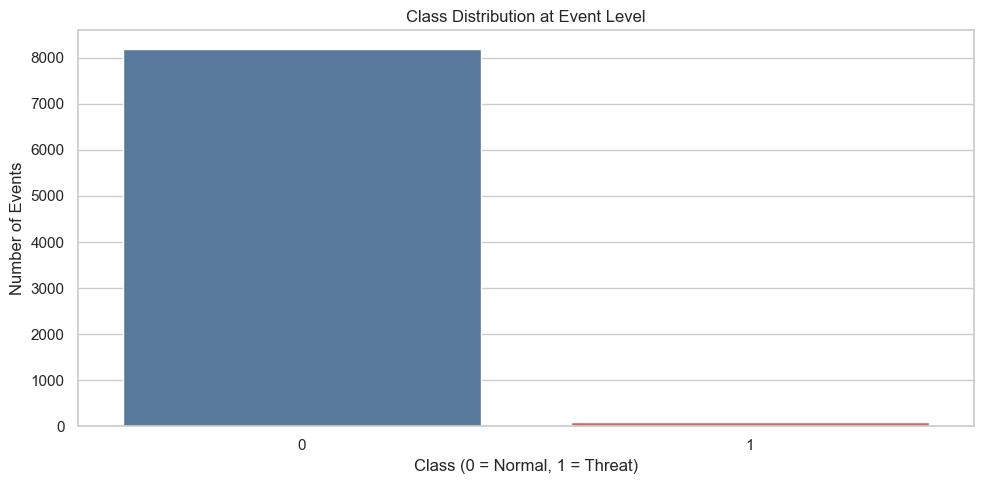

In [4]:
label_counts = events["label"].value_counts().sort_index()
label_percent = (label_counts / label_counts.sum() * 100).round(2)
class_summary = pd.DataFrame({"count": label_counts, "percent": label_percent})
class_summary.index = class_summary.index.map({0: "Normal", 1: "Threat"})
display(class_summary)

ax = sns.countplot(data=events, x="label", hue="label", palette={0: "#4C78A8", 1: "#E45756"}, legend=False)
ax.set_title("Class Distribution at Event Level")
ax.set_xlabel("Class (0 = Normal, 1 = Threat)")
ax.set_ylabel("Number of Events")
plt.tight_layout()
plt.show()

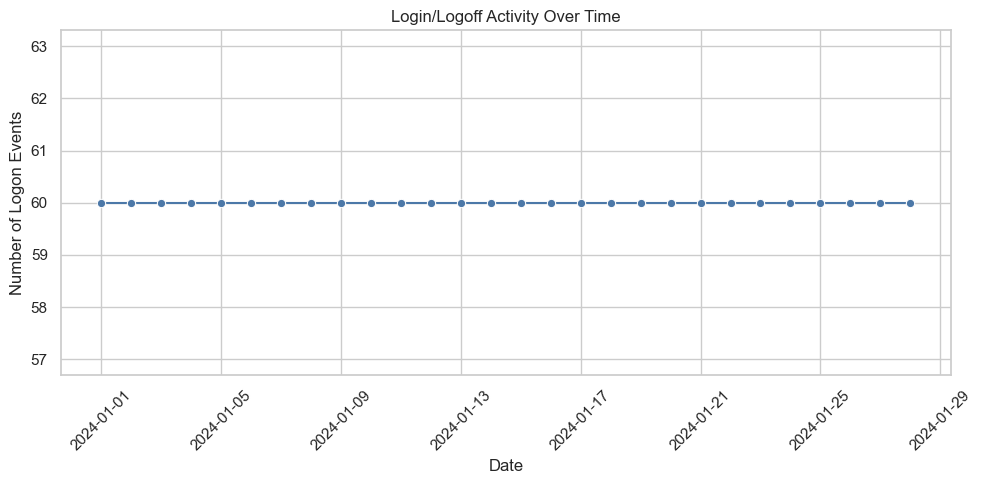

In [5]:
logon_events = events[events["event_type"].eq("logon")].copy()
logon_events["date"] = logon_events["timestamp"].dt.date
login_over_time = logon_events.groupby("date").size().reset_index(name="logon_events")

sns.lineplot(data=login_over_time, x="date", y="logon_events", marker="o", color="#4C78A8")
plt.title("Login/Logoff Activity Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Logon Events")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

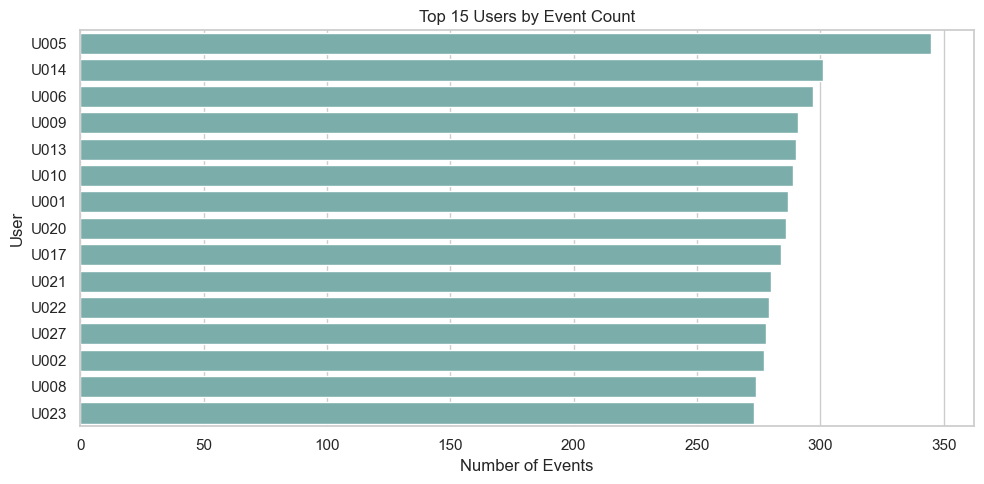

In [6]:
top_users = events["user"].value_counts().head(15).reset_index()
top_users.columns = ["user", "event_count"]

sns.barplot(data=top_users, y="user", x="event_count", color="#72B7B2")
plt.title("Top 15 Users by Event Count")
plt.xlabel("Number of Events")
plt.ylabel("User")
plt.tight_layout()
plt.show()

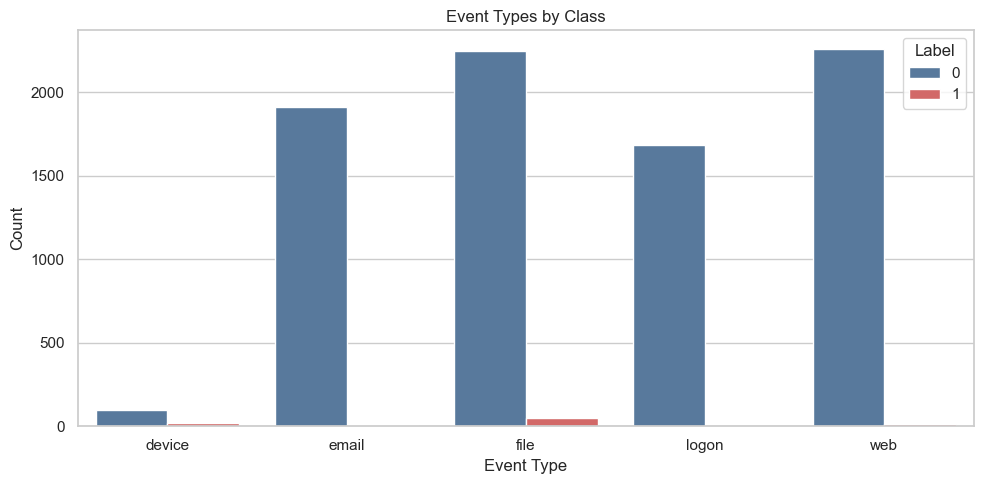

In [7]:
event_type_by_label = (
    events.groupby(["event_type", "label"])
    .size()
    .reset_index(name="count")
)

sns.barplot(data=event_type_by_label, x="event_type", y="count", hue="label", palette={0: "#4C78A8", 1: "#E45756"})
plt.title("Event Types by Class")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.legend(title="Label")
plt.tight_layout()
plt.show()

## Preprocessing and Feature Engineering

Raw logs are aggregated into user/time-window features. The default window is one day per user

Feature groups include:

- Login frequency and logoff counts
- After-hours activity and after-hours logons
- File access counts and unique files
- Device usage counts
- Email and web activity counts
- Email attachment and size totals when available
- Rolling activity spike z-scores by user

Categorical information such as the most common PC is encoded with one-hot variables in the feature matrix. Numeric scaling is handled inside the model pipelines for models that require it.

In [8]:
feature_df = aggregate_user_time_window(events, window="1D")
print("Feature table shape:", feature_df.shape)
display(feature_df.head())

feature_label_summary = feature_df["label"].value_counts().sort_index().rename_axis("label").reset_index(name="windows")
display(feature_label_summary)

Feature table shape: (840, 30)


,user,window_start,total_events,after_hours_count,after_hours_rate,weekend_count,weekend_rate,unique_pcs,most_common_pc,logon_count,...,email_attachment_count,email_size_total,label,total_events_spike_z,file_count_spike_z,device_count_spike_z,email_count_spike_z,web_count_spike_z,max_spike_z,unusual_activity_spike
0,U001,2024-01-01,15,1,0.066667,0,0.0,1,PC001,2,...,0,7500.0,0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0
1,U001,2024-01-02,21,0,0.000000,0,0.0,1,PC001,2,...,0,9000.0,0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0
2,U001,2024-01-03,6,0,0.000000,0,0.0,1,PC001,2,...,0,1500.0,0,-2.828427,-1.414214,0.0,-6.363961,-4.949747,0.000000,0
3,U001,2024-01-04,12,0,0.000000,0,0.0,1,PC001,2,...,0,3000.0,0,-0.264906,-0.545545,0.0,-0.755929,0.800641,0.800641,0
4,U001,2024-01-05,10,0,0.000000,0,0.0,1,PC001,2,...,0,3000.0,0,-0.560449,0.665410,0.0,-0.630126,-1.981015,0.665410,0


,label,windows
0,0,835
1,1,5


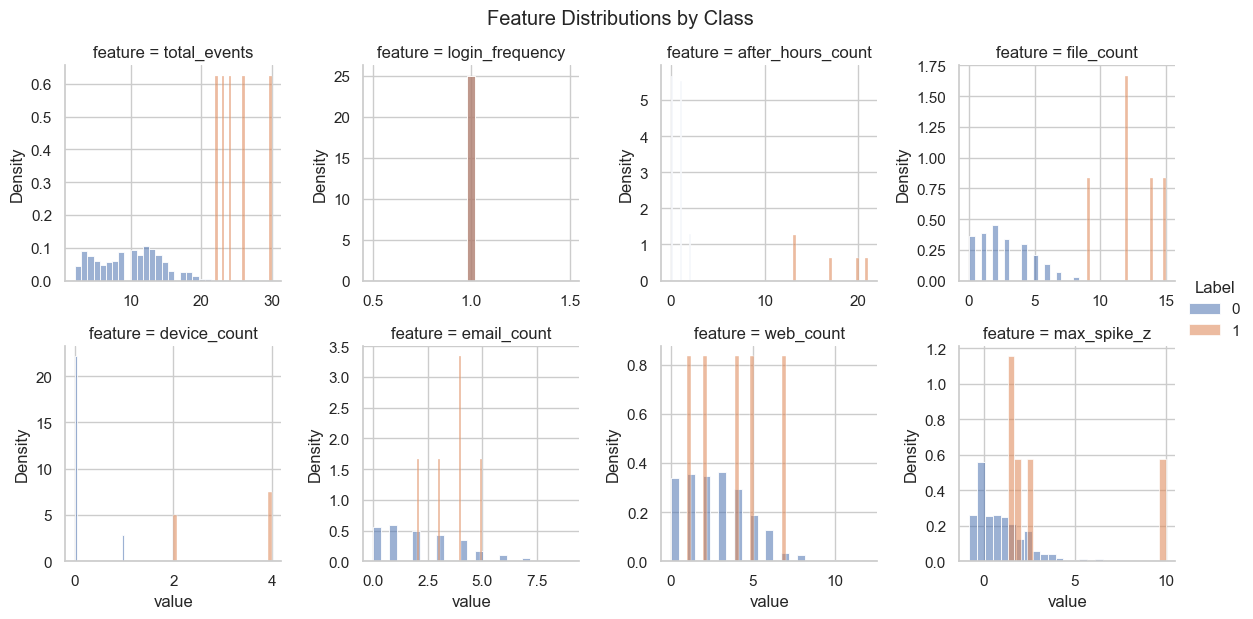

In [9]:
plot_features = [
    "total_events",
    "login_frequency",
    "after_hours_count",
    "file_count",
    "device_count",
    "email_count",
    "web_count",
    "max_spike_z",
]
plot_features = [col for col in plot_features if col in feature_df.columns]

melted = feature_df.melt(id_vars="label", value_vars=plot_features, var_name="feature", value_name="value")

g = sns.FacetGrid(melted, col="feature", hue="label", col_wrap=4, sharex=False, sharey=False, height=3)
g.map_dataframe(sns.histplot, x="value", bins=25, stat="density", common_norm=False, alpha=0.55)
g.add_legend(title="Label")
g.fig.suptitle("Feature Distributions by Class", y=1.03)
plt.show()

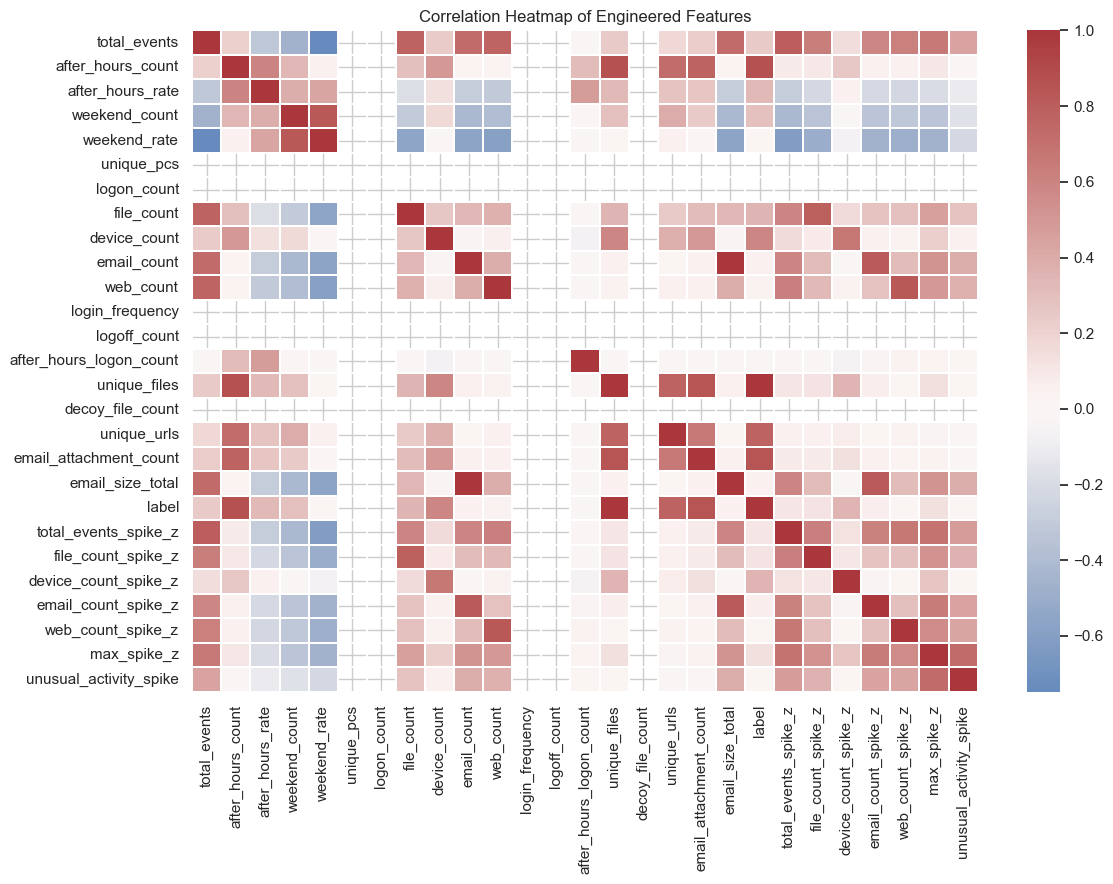

In [10]:
numeric_features = feature_df.select_dtypes(include=[np.number])
correlation = numeric_features.corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(correlation, cmap="vlag", center=0, linewidths=0.2)
plt.title("Correlation Heatmap of Engineered Features")
plt.tight_layout()
plt.show()

## Prepare Train/Test Data

The train/test split is stratified when enough positive cases exist. This matters because insider threat labels are usually rare and a random split can accidentally put too few threat windows in the test set.

In [11]:
X, y = prepare_feature_matrix(feature_df)
print("Model matrix shape:", X.shape)
print("Label counts:")
display(y.value_counts().rename_axis("label").reset_index(name="count"))

enough_classes = y.nunique() == 2 and y.value_counts().min() >= 2

# If the notebook was run out of order, feature_df may be stale even though
# the current events table has positive labels. Regenerate once before failing.
if not enough_classes and "events" in globals() and "label" in events.columns and events["label"].sum() > 0:
    print("feature_df did not contain both classes, so it is being regenerated from the current events table.")
    feature_df = aggregate_user_time_window(events, window="1D")
    X, y = prepare_feature_matrix(feature_df)
    print("Updated label counts:")
    display(y.value_counts().rename_axis("label").reset_index(name="count"))
    enough_classes = y.nunique() == 2 and y.value_counts().min() >= 2

if not enough_classes:
    raise ValueError(
        "The feature table still does not contain enough normal and threat windows. "
        "Restart the kernel, then run all cells from the top so the fixed answer-key loader is used."
    )

stratify = y if y.value_counts().min() >= 2 else None
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=stratify,
)

positive_train_idx = y_train[y_train == 1].index
normal_train_idx = y_train[y_train == 0].index

if len(normal_train_idx) > MAX_NORMAL_TRAIN_ROWS:
    sampled_normal_idx = y_train.loc[normal_train_idx].sample(
        n=MAX_NORMAL_TRAIN_ROWS,
        random_state=RANDOM_STATE,
    ).index
else:
    sampled_normal_idx = normal_train_idx

model_train_idx = positive_train_idx.union(sampled_normal_idx)
X_train_model = X_train.loc[model_train_idx]
y_train_model = y_train.loc[model_train_idx]

print("Training rows:", len(X_train))
print("Model training rows:", len(X_train_model))
print("Test rows:", len(X_test))
print("Training positive rate:", round(y_train.mean(), 4))
print("Model training positive rate:", round(y_train_model.mean(), 4))
print("Test positive rate:", round(y_test.mean(), 4))

Model matrix shape: (840, 56)
Label counts:


,label,count
0,0,835
1,1,5


Training rows: 630
Model training rows: 630
Test rows: 210
Training positive rate: 0.0063
Model training positive rate: 0.0063
Test positive rate: 0.0048


## Optional Cross-Validation

Cross-validation is useful, but with very rare threat labels it may not be possible to create many folds. The code below uses recall as the scoring metric because missed threats are especially costly.

In [12]:
cv_rows = []
min_class_count = int(y_train_model.value_counts().min())

if min_class_count >= 3:
    n_splits = min(3, min_class_count)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    cv_models = get_supervised_models(RANDOM_STATE)
    cv_models.pop("Support Vector Machine", None)  # RBF SVM cross-validation is slow on this dataset.

    for name, model in cv_models.items():
        scores = cross_val_score(model, X_train_model, y_train_model, cv=cv, scoring="recall")
        cv_rows.append({"model": name, "mean_recall": scores.mean(), "std_recall": scores.std(), "folds": n_splits})
    cv_results = pd.DataFrame(cv_rows).sort_values("mean_recall", ascending=False)
    display(cv_results)
    print("SVM cross-validation skipped to keep runtime manageable; SVM is still trained and evaluated below.")
else:
    print("nope")

,model,mean_recall,std_recall,folds
0,Logistic Regression,1.000000,0.000000,3
1,Random Forest,0.833333,0.235702,3


SVM cross-validation skipped to keep runtime manageable; SVM is still trained and evaluated below.


## Modeling

This project compares supervised classifiers against anomaly detection models.

Supervised models learn from known normal and threat labels:

- Logistic Regression
- Random Forest
- Support Vector Machine

Anomaly detection models learn what normal activity looks like and flag unusual windows:

- Isolation Forest
- One-Class SVM

When labels are available, anomaly models are fit on normal training rows only.

In [13]:
supervised_models = fit_models(get_supervised_models(RANDOM_STATE), X_train_model, y_train_model)

estimated_contamination = max(float(y_train_model.mean()), 0.01)
anomaly_models = fit_anomaly_models(
    get_anomaly_models(contamination=estimated_contamination, random_state=RANDOM_STATE),
    X_train_model,
    y_train_model,
)

print("Fitted supervised models:", list(supervised_models.keys()))
print("Fitted anomaly models:", list(anomaly_models.keys()))
print("Estimated contamination:", round(estimated_contamination, 4))

Fitted supervised models: ['Logistic Regression', 'Random Forest', 'Support Vector Machine']
Fitted anomaly models: ['Isolation Forest', 'One-Class SVM']
Estimated contamination: 0.01


## Evaluation

The most important metrics for this problem are recall and false negative rate.

- High recall means the model catches more actual threat windows.
- Low false negative rate means fewer threats are missed.
- Precision is still important because too many false positives can overwhelm analysts.
- ROC-AUC summarizes ranking quality across thresholds.

In [14]:
supervised_results = evaluate_supervised_models(supervised_models, X_test, y_test)
anomaly_results = evaluate_anomaly_models(anomaly_models, X_test, y_test)

comparison = pd.concat([supervised_results, anomaly_results], ignore_index=True)
comparison = comparison.sort_values(
    ["recall", "false_negative_rate", "f1"],
    ascending=[False, True, False],
).reset_index(drop=True)

display(comparison.style.format({
    "accuracy": "{:.3f}",
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}",
    "false_negative_rate": "{:.3f}",
    "roc_auc": "{:.3f}",
}))

,model,type,accuracy,precision,recall,f1,false_negative_rate,roc_auc
0,Logistic Regression,supervised,1.000,1.000,1.000,1.000,0.000,1.000
1,Support Vector Machine,supervised,1.000,1.000,1.000,1.000,0.000,1.000
2,Isolation Forest,anomaly,0.986,0.250,1.000,0.400,0.000,1.000
3,Random Forest,supervised,0.995,0.000,0.000,0.000,1.000,1.000
4,One-Class SVM,anomaly,0.686,0.000,0.000,0.000,1.000,0.000


Best model by recall/FNR/F1 ordering: Logistic Regression (supervised)


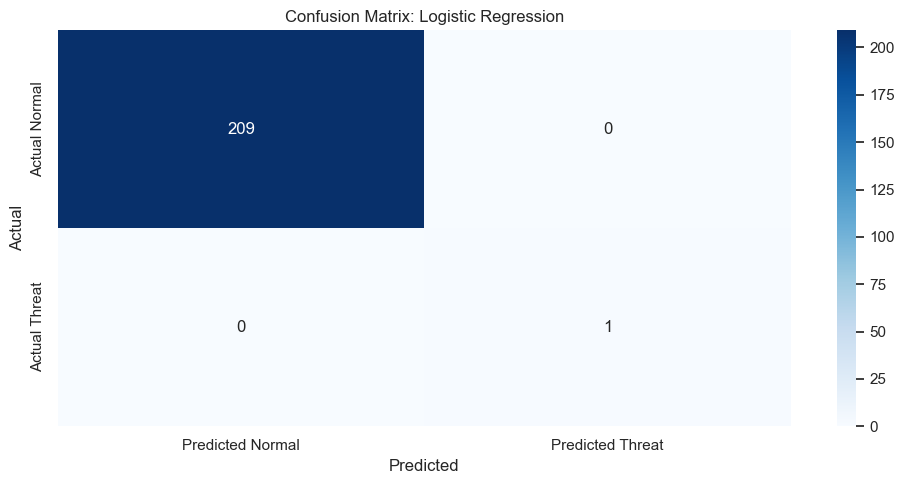

In [15]:
best = comparison.iloc[0]
best_name = best["model"]
best_type = best["type"]
print(f"Best model by recall/FNR/F1 ordering: {best_name} ({best_type})")

if best_type == "supervised":
    best_model = supervised_models[best_name]
    y_pred_best = best_model.predict(X_test)
else:
    best_model = anomaly_models[best_name]
    y_pred_best = predict_anomaly_labels(best_model, X_test)

plot_confusion_matrix(y_test, y_pred_best, title=f"Confusion Matrix: {best_name}")
plt.show()

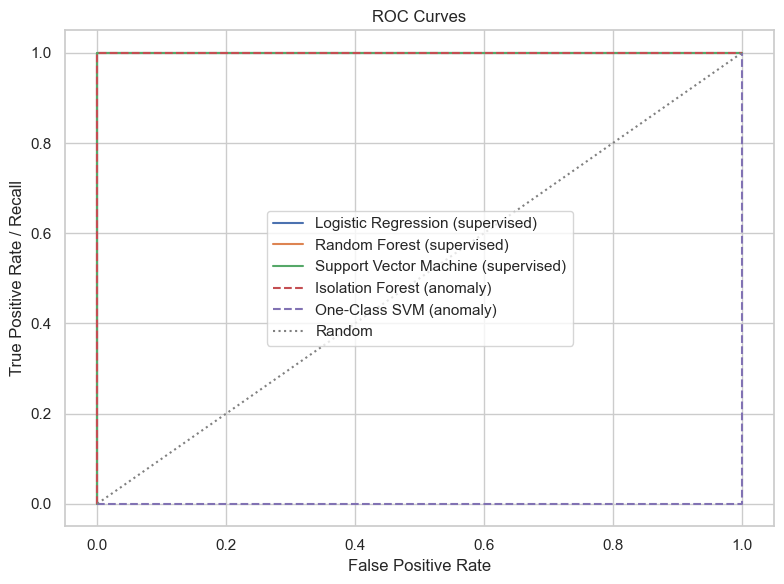

In [16]:
if y_test.nunique() == 2:
    plot_roc_curves(supervised_models, anomaly_models, X_test, y_test)
    plt.show()
else:
    print("ROC curves require both classes in the test set.")

## Feature Importance and Interpretation

Random Forest feature importance provides a simple way to inspect which engineered behaviors were most useful. This does not prove causation, but it helps connect model predictions back to security-relevant behaviors.

,feature,importance
0,total_events,0.167240
1,file_count,0.159207
2,device_count,0.115447
3,after_hours_count,0.099574
4,after_hours_rate,0.078092
5,unique_files,0.072995
6,most_common_pc_PC005,0.063547
7,file_count_spike_z,0.050061
8,total_events_spike_z,0.041891
9,weekend_count,0.030612


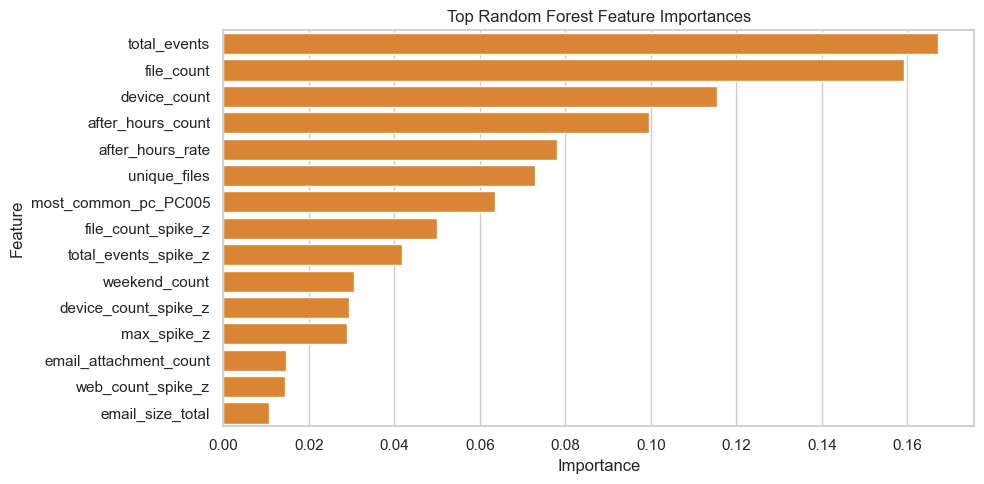

In [17]:
rf_model = supervised_models.get("Random Forest")

if rf_model is not None and hasattr(rf_model, "feature_importances_"):
    importances = (
        pd.Series(rf_model.feature_importances_, index=X_train.columns)
        .sort_values(ascending=False)
        .head(15)
        .reset_index()
    )
    importances.columns = ["feature", "importance"]
    display(importances)

    sns.barplot(data=importances, y="feature", x="importance", color="#F58518")
    plt.title("Top Random Forest Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("Random Forest feature importances are not available.")

## Final Discussion

The best model should be selected primarily by recall and false negative rate rather than accuracy alone. Insider threat detection is a rare-event problem, so a model can appear accurate while still missing the most important cases.

In this workflow, useful features are expected to include after-hours activity, file access counts, device usage counts, email/web activity counts, and sudden spikes relative to a user's recent baseline. The Random Forest model is often a strong  baseline because it can capture non-linear patterns and provide feature importance. Logistic Regression is easier to explain, while SVM can perform well but is less interpretable. Isolation Forest and One-Class SVM are useful comparisons when labels are missing or incomplete.

Limitations include class imbalance, possible incomplete labels, synthetic CERT generalization limits and the fact that unusual behavior is not always malicious. In a real organization, these predictions should support human analyst review rather than automatically accuse a user.

Future improvements could include testing hourly windows, adding peer-group baselines by role or department, tuning thresholds for higher recall, using time-aware validation and adding explainability tools for analyst review.